## Plotting National Weather Service Local Storm Reports
### Written By Jared Rennie (@jjrennie)

This Notebook will download one year's worth of Local Storm Reports from the <a href='https://mesonet.agron.iastate.edu/lsr/' target='_blank'>Iowa Environment Mesonet</a> repository and 
- Plot each LSR (point)
- Aggregate and plot by state

### What You Need
First off, the entire codebase works in Python 3. In addition to base Python, you will need the following packages installed:

- requests (to access the IEM api)
- pathlib and zipfile (to move and unzip data from IEM)
- numpy, pandas and geopandas (to slice annd dice the data)
- matplotlib and cartopy (to plot!)

The "easiest" way is to install these is by installing <a href='https://www.anaconda.com/' target='_blank'>anaconda</a>, and then applying <a href='https://conda-forge.org/' target='_blank'>conda-forge</a>. Afterward, then you can install the above packages.

### Importing Packages
Assuming you did the above, it should (in theory) import everything no problem:

In [1]:
%matplotlib inline

# Import Packages
import requests
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

print('SUCCESS')

SUCCESS


If you made it this far, great!

### Insert Arguments
We need 3 arguments
- Year to get data
- Local Storm Report Type (We will Default to Tornado, see <a href = 'https://mesonet.agron.iastate.edu/request/gis/lsrs.phtml' target='_blank'>this page</a> for other variables)
- Author

**Change the arguments below to your liking**

In [2]:
inYear = 2025
#inVar= 'FLASH+FLOOD'
inVar= 'TORNADO'
author= 'Not Jared Rennie'

### Read in State Shapefile
Inside this notebook is a state shapefile we will use to help plot and aggregate data. Let's read that in. We are also going to split the shapefile 4 ways
- CONUS (Lower 48 States)
- Alaska Only
- Hawaii Only
- Puerto Rico Only

This will help us with plotting later

In [3]:
# Read in State Shapfile
state_shapefile = "./input_shapefile/cb_2024_us_state_500k.shp"
inStates=gpd.read_file(state_shapefile)

# Split by region
ak_shp = inStates[inStates["STUSPS"] == "AK"]
hi_shp = inStates[inStates["STUSPS"] == "HI"]
pr_shp = inStates[inStates["STUSPS"] == "PR"]
conus_shp = inStates[~inStates["STUSPS"].isin(["AK", "HI", "PR"])]
ak_shp

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
17,02,01785533,0400000US02,02,AK,Alaska,00,1479508971743,244710526650,"MULTIPOLYGON (((-132.48252 56.57015, -132.4694..."


### Get IEM Data
We will now tap into the API to download the data locally.

In [4]:
# Variables
inLink = "https://mesonet.agron.iastate.edu/cgi-bin/request/gis/lsr.py?wfo=ALL&state=_ALL"

# Output directory
outDir = Path("input_iem")
outDir.mkdir(parents=True, exist_ok=True)

# Output zip file (inside source_iem)
outFile = outDir / f"{inYear}_{inVar}.zip"

# Build URL
inLink = (
    f"{inLink}"
    f"&type={inVar}"
    f"&year1={inYear}&month1=1&day1=1&hour1=0&minute1=0"
    f"&year2={inYear}&month2=12&day2=31&hour2=23&minute2=59"
    f"&fmt=shp"
)

# Download
response = requests.get(inLink, stream=True)
response.raise_for_status()

with open(outFile, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

# Unzip into source_iem
with zipfile.ZipFile(outFile, "r") as zip_ref:
    zip_ref.extractall(outDir)

print(f"Downloaded and extracted to: {outDir.resolve()}")

Downloaded and extracted to: /home/jovyan/work/ARCHIVE/2025_ANNUAL/notebook/input_iem


### Read in IEM Data
We will use pandas to read in the data

In [5]:
inFile=f"input_iem/lsr_{inYear}01010000_{inYear}12312359.csv"
inData = pd.read_csv(inFile,sep=",",usecols=['VALID','VALID2','LAT','LON','STATE'])
lsr_total=len(inData)
inData

,VALID,VALID2,LAT,LON,STATE
0,202501040118,2025/01/04 01:18,40.34,-122.09,CA
1,202501040118,2025/01/04 01:18,40.34,-122.09,CA
2,202501052005,2025/01/05 20:05,33.88,-91.68,AR
3,202501052005,2025/01/05 20:05,33.92,-91.66,AR
4,202501052019,2025/01/05 20:19,32.86,-92.19,LA
...,...,...,...,...,...
1728,202512282153,2025/12/28 21:53,40.90,-87.77,IL
1729,202512282245,2025/12/28 22:45,39.64,-87.85,IL
1730,202512290018,2025/12/29 00:18,39.03,-87.17,IN
1731,202512290036,2025/12/29 00:36,38.19,-87.66,IN


We will once again split by the 4 regions (CONUS, AK, HI, PR)

In [6]:
# Split by region
ak = inData[inData["STATE"] == "AK"]
hi = inData[inData["STATE"] == "HI"]
pr = inData[inData["STATE"] == "PR"]
conus = inData[~inData["STATE"].isin(["AK", "HI", "PR"])]

Now for the fun part
### Plot (ALL POINTS)
This block of code will plot all LSR's on the map, and will also plot by CONUS/AK/PR/HI

PLOTTING


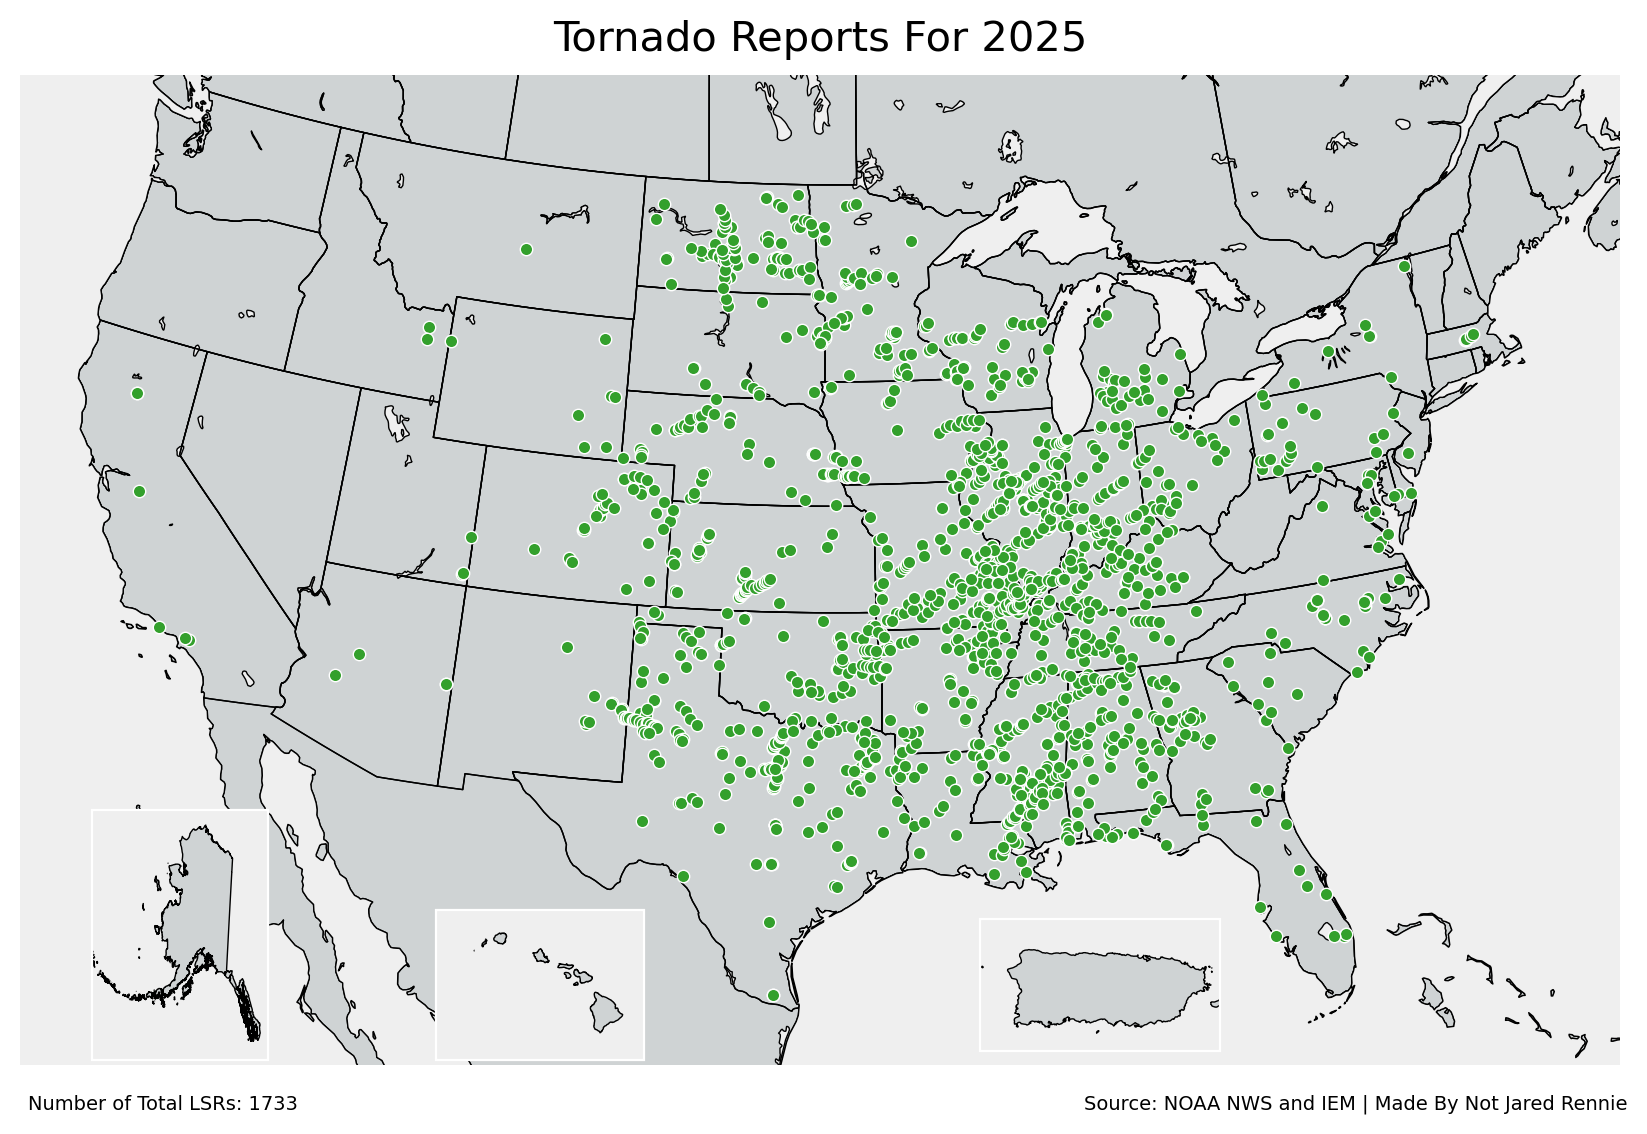

In [7]:
# Plotting Arguments
dpi=200
land_hex='#cfd3d4'  # ESRI Light Gray Canvas
ocean_hex='#efefef' # ESRI Light Gray Canvas
edgecolor='white'
lsr_color='#33a02c'
outVar=inVar.replace('+','-').title()

# Set Up Figure
print('PLOTTING')
fig= plt.figure(num=1, figsize=(8,5), dpi=dpi, facecolor='w', edgecolor='k')
        
# CONUS AXES
conus_ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.LambertConformal())
conus_ax.set_facecolor(ocean_hex)
conus_ax.spines['geo'].set_edgecolor(edgecolor)
conus_ax.set_extent([-120, -73, 22, 50], crs=ccrs.Geodetic())
        
# ALASKA AXES
ak_ax = fig.add_axes([-0.3, 0.01, 0.80, 0.25], projection=ccrs.Orthographic(central_longitude=-134, central_latitude=57))
ak_ax.set_facecolor(ocean_hex) 
ak_ax.spines['geo'].set_edgecolor(edgecolor)
ak_ax.set_extent([-184, -128, 53, 67], crs=ccrs.Geodetic())  

# HAWAII AXES
hi_ax = fig.add_axes([0.25, 0.01, 0.15, 0.15], projection=ccrs.Mercator())
hi_ax.set_facecolor(ocean_hex)
hi_ax.spines['geo'].set_edgecolor(edgecolor)
hi_ax.set_extent([-162, -154, 18, 23], crs=ccrs.Geodetic())
        
# PUERTO RICO AXES
pr_ax = fig.add_axes([0.60, 0.01, 0.15, 0.15], projection=ccrs.Mercator())
pr_ax.set_facecolor(ocean_hex)
pr_ax.spines['geo'].set_edgecolor(edgecolor)
pr_ax.set_extent([-67.5, -65.5, 17.75, 18.75], crs=ccrs.Geodetic())    
        
# Add other Features
conus_ax.add_feature(cfeature.LAND,linewidth=0.5,facecolor=land_hex,edgecolor='black',zorder=3)
conus_ax.add_feature(cfeature.LAKES,linewidth=0.5,facecolor=ocean_hex,edgecolor='black',zorder=7)
conus_ax.add_feature(cfeature.STATES,linewidth=0.5,facecolor=land_hex,edgecolor='black',zorder=5)
conus_ax.add_feature(cfeature.STATES,linewidth=0.5,edgecolor='black',zorder=7)
conus_ax.add_feature(cfeature.OCEAN,linewidth=0.5,facecolor=ocean_hex,edgecolor='black',zorder=7)

# Add Other Regions
ak_shp.plot(ax=ak_ax,edgecolor='black',facecolor=land_hex,linewidth=0.5,transform=ccrs.PlateCarree())
hi_shp.plot(ax=hi_ax,edgecolor='black',facecolor=land_hex,linewidth=0.5,transform=ccrs.PlateCarree())
pr_shp.plot(ax=pr_ax,edgecolor='black',facecolor=land_hex,linewidth=0.5,transform=ccrs.PlateCarree())

# Plot Data For Each LSR
ak_ax.scatter(ak['LON'], ak['LAT'], marker='o', s=20,color=lsr_color,edgecolors=edgecolor,linewidths=0.5,transform=ccrs.PlateCarree(),zorder=12)
hi_ax.scatter(hi['LON'], hi['LAT'], marker='o', s=20,color=lsr_color,edgecolors=edgecolor,linewidths=0.5,transform=ccrs.PlateCarree(),zorder=12)
pr_ax.scatter(pr['LON'], pr['LAT'], marker='o', s=20,color=lsr_color,edgecolors=edgecolor,linewidths=0.5,transform=ccrs.PlateCarree(),zorder=12)
conus_ax.scatter(conus['LON'], conus['LAT'], marker='o', s=20,color=lsr_color,edgecolors=edgecolor,linewidths=0.5,transform=ccrs.PlateCarree(),zorder=12)

# Add Titles
plt.suptitle(str(outVar)+' Reports For '+str(inYear),size=15,color='black',y=1.05) 
conus_ax.annotate('Number of Total LSRs: '+str(lsr_total),xy=(0.005, -0.05), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='left', verticalalignment='bottom')
conus_ax.annotate('Source: NOAA NWS and IEM | Made By '+str(author),xy=(1.005, -0.05), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='right', verticalalignment='bottom')
plt.savefig('lsr_point_'+str(outVar)+'_'+str(inYear)+'.png',bbox_inches='tight')
plt.show()

### Aggregate IEM Data By State
Now we will aggregate the points by state by joining the state shapefile with the data from IEM

In [8]:
state_count_shp = inStates.merge(
    inData['STATE'].value_counts().rename('lsr_count').reset_index().set_axis(['STUSPS','lsr_count'], axis=1),
    on='STUSPS',
    how='left'
).fillna({'lsr_count': 0})
vmin=state_count_shp['lsr_count'].min()
vmax=state_count_shp['lsr_count'].max()
print(vmin,vmax)

# Split By Region
ak_count_shp = state_count_shp[state_count_shp["STUSPS"] == "AK"]
hi_count_shp = state_count_shp[state_count_shp["STUSPS"] == "HI"]
pr_count_shp = state_count_shp[state_count_shp["STUSPS"] == "PR"]
conus_count_shp = state_count_shp[~state_count_shp["STUSPS"].isin(["AK","HI", "PR", "DC", "AS", "VI", "MP", "GU"])]

0.0 169.0


### Save to Shapefile
Let's save this as a shapefile, in case you want to put this into another plotting program like QGIS or ArcGIS Pro

In [9]:
outShp='./output_shapefile/lsr_state_'+str(outVar)+'_'+str(inYear)+'.shp'
state_count_shp.to_file(outShp)
print('Written to ',outShp)

Written to  ./output_shapefile/lsr_state_Tornado_2025.shp


### Plot By State

PLOTTING


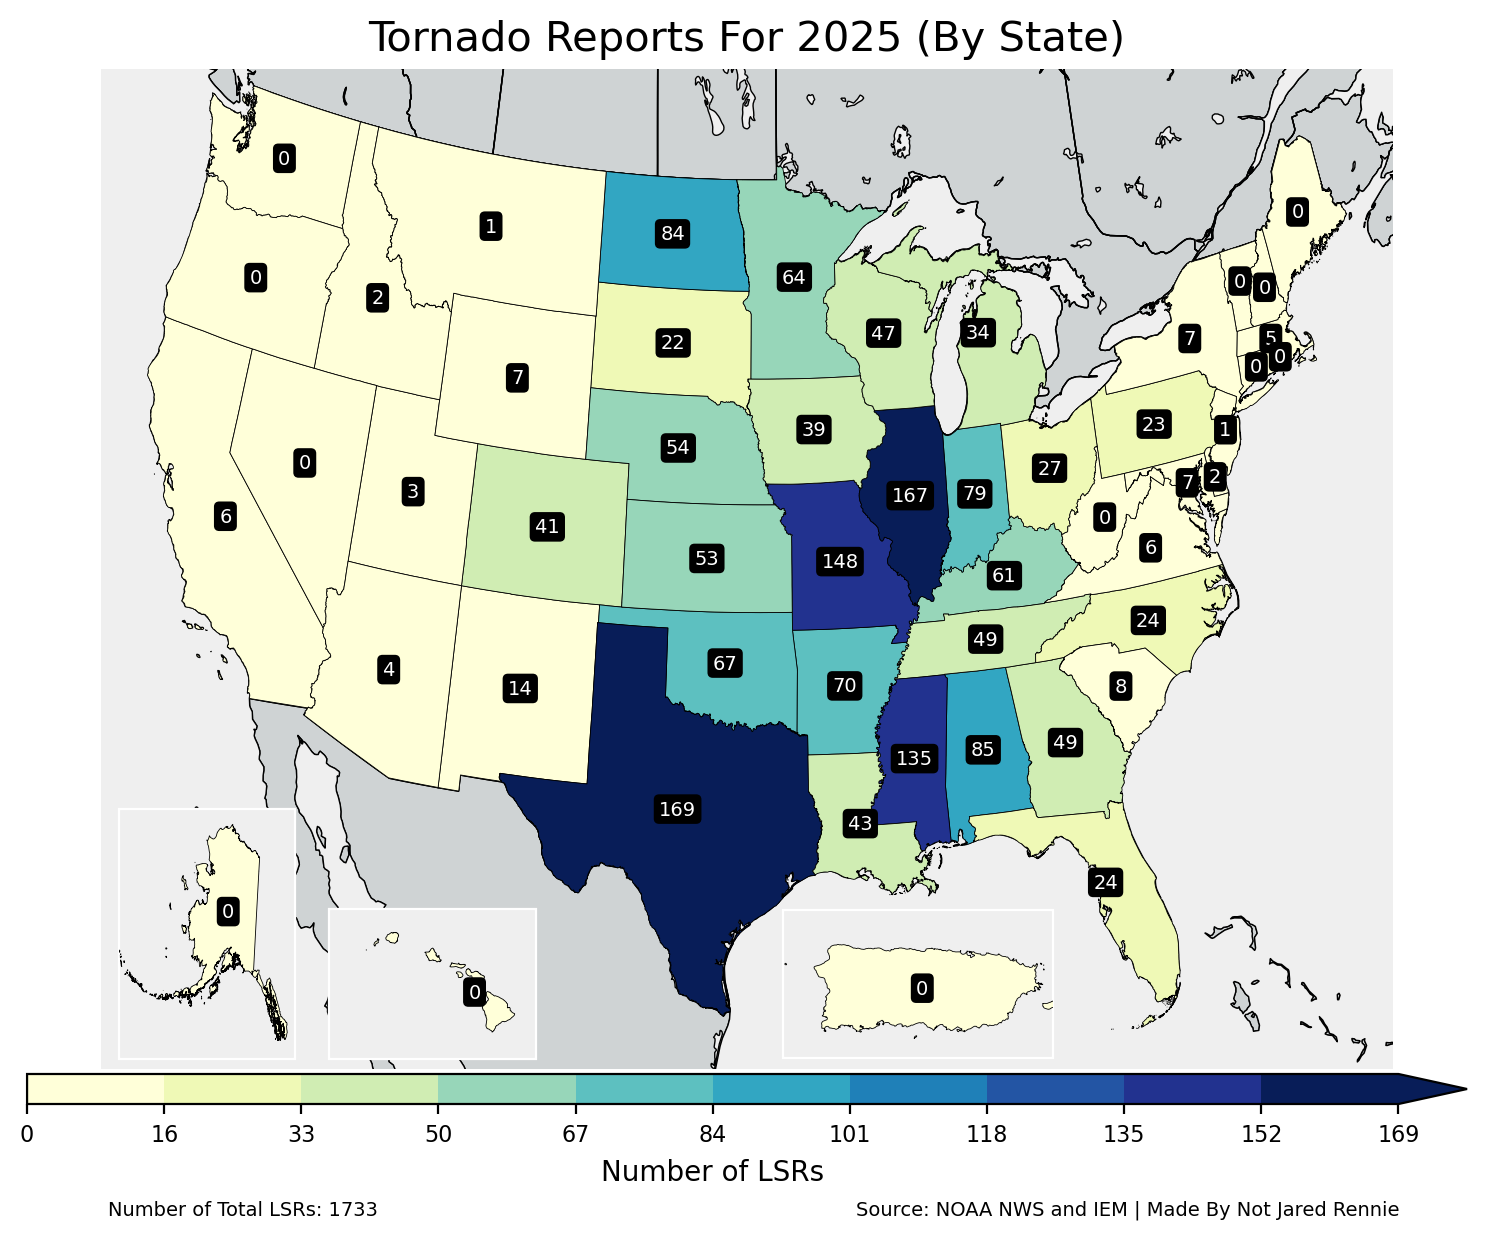

In [10]:
# Plotting Arguments
dpi=200
land_hex='#cfd3d4'  # ESRI Light Gray Canvas
ocean_hex='#efefef' # ESRI Light Gray Canvas
edgecolor='white'
lsr_color='#33a02c'

# Set Up Figure
print('PLOTTING')
fig= plt.figure(num=1, figsize=(9,5), dpi=dpi, facecolor='w', edgecolor='k')
        
# CONUS AXES
conus_ax = fig.add_axes([0, 0, 1, 1], projection=ccrs.LambertConformal())
conus_ax.set_facecolor(ocean_hex)
conus_ax.spines['geo'].set_edgecolor(edgecolor)
conus_ax.set_extent([-120, -73, 22, 50], crs=ccrs.Geodetic())

# ALASKA AXES
ak_ax = fig.add_axes([-0.2, 0.01, 0.80, 0.25], projection=ccrs.Orthographic(central_longitude=-134, central_latitude=57))
ak_ax.set_facecolor(ocean_hex) 
ak_ax.spines['geo'].set_edgecolor(edgecolor)
ak_ax.set_extent([-184, -128, 53, 67], crs=ccrs.Geodetic()) 

# HAWAII AXES
hi_ax = fig.add_axes([0.25, 0.01, 0.15, 0.15], projection=ccrs.Mercator())
hi_ax.set_facecolor(ocean_hex)
hi_ax.spines['geo'].set_edgecolor(edgecolor)
hi_ax.set_extent([-162, -154, 18, 23], crs=ccrs.Geodetic())
        
# PUERTO RICO AXES
pr_ax = fig.add_axes([0.52, 0.01, 0.15, 0.15], projection=ccrs.Mercator())
pr_ax.set_facecolor(ocean_hex)
pr_ax.spines['geo'].set_edgecolor(edgecolor)
pr_ax.set_extent([-67.5, -65.5, 17.75, 18.75], crs=ccrs.Geodetic())    
        
# Add other Features
conus_ax.add_feature(cfeature.LAND,linewidth=0.5,facecolor=land_hex,edgecolor='black',zorder=3)
conus_ax.add_feature(cfeature.LAKES,linewidth=0.5,facecolor=ocean_hex,edgecolor='black',zorder=7)
conus_ax.add_feature(cfeature.STATES,linewidth=0.5,facecolor=land_hex,edgecolor='black',zorder=5)
conus_ax.add_feature(cfeature.STATES,linewidth=0.5,edgecolor='black',zorder=7)
conus_ax.add_feature(cfeature.OCEAN,linewidth=0.5,facecolor=ocean_hex,edgecolor='black',zorder=7)

# Build Color Map
cmap = plt.cm.YlGnBu
bounds = np.linspace(vmin, vmax, 11,dtype='i') 
extend='max'
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# Plot Data For Each LSR (By State)
conus_count_shp.plot(ax=conus_ax,column='lsr_count',legend=False,cmap=cmap,norm=norm,edgecolor='black',linewidth=0.3,transform=ccrs.PlateCarree(),zorder=10)
for idx, row in conus_count_shp.iterrows():  
    conus_ax.text(row['geometry'].centroid.x, row['geometry'].centroid.y,int(row['lsr_count']),horizontalalignment='center',
                  verticalalignment='center',fontsize=7,color='white',transform=ccrs.PlateCarree(),zorder=11,
                  bbox=dict(facecolor='black',edgecolor='black',boxstyle='round,pad=0.2'))

hi_count_shp.plot(ax=hi_ax,column='lsr_count',legend=False,cmap=cmap,norm=norm,edgecolor='black',linewidth=0.3,transform=ccrs.PlateCarree(),zorder=10)
for idx, row in hi_count_shp.iterrows():  
    hi_ax.text(row['geometry'].centroid.x, row['geometry'].centroid.y,int(row['lsr_count']),horizontalalignment='center',
                  verticalalignment='center',fontsize=7,color='white',transform=ccrs.PlateCarree(),zorder=11,
                  bbox=dict(facecolor='black',edgecolor='black',boxstyle='round,pad=0.2'))

pr_count_shp.plot(ax=pr_ax,column='lsr_count',legend=False,cmap=cmap,norm=norm,edgecolor='black',linewidth=0.3,transform=ccrs.PlateCarree(),zorder=10)
for idx, row in pr_count_shp.iterrows():  
    pr_ax.text(row['geometry'].centroid.x, row['geometry'].centroid.y,int(row['lsr_count']),horizontalalignment='center',
                  verticalalignment='center',fontsize=7,color='white',transform=ccrs.PlateCarree(),zorder=11,
                  bbox=dict(facecolor='black',edgecolor='black',boxstyle='round,pad=0.2'))

ak_count_shp.plot(ax=ak_ax,column='lsr_count',legend=False,cmap=cmap,norm=norm,edgecolor='black',linewidth=0.3,transform=ccrs.PlateCarree(),zorder=10)
for idx, row in ak_count_shp.iterrows():  
    ak_ax.text(row['geometry'].centroid.x, row['geometry'].centroid.y,int(row['lsr_count']),horizontalalignment='center',
                  verticalalignment='center',fontsize=7,color='white',transform=ccrs.PlateCarree(),zorder=11,
                  bbox=dict(facecolor='black',edgecolor='black',boxstyle='round,pad=0.2'))

# Add Colorbar
unit="Number of LSRs"
cax = fig.add_axes([0.1, -0.035, 0.8, 0.03])
cbar = plt.colorbar(sm, cax=cax, orientation='horizontal', ticks=bounds, spacing='uniform', extend=extend)
cbar.ax.tick_params(labelsize=8)
cbar.set_label(unit, size=10)

# Add Titles
plt.suptitle(str(outVar)+' Reports For '+str(inYear)+' (By State)',size=15,color='black',y=1.05) 
conus_ax.annotate('Number of Total LSRs: '+str(lsr_total),xy=(0.005, -0.15), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='left', verticalalignment='bottom')
conus_ax.annotate('Source: NOAA NWS and IEM | Made By '+str(author),xy=(1.005, -0.15), xycoords='axes fraction', fontsize=7,color='black',horizontalalignment='right', verticalalignment='bottom')
plt.savefig('lsr_state_'+str(outVar)+'_'+str(inYear)+'.png',bbox_inches='tight')
plt.show()

**Congrats on completing this notebook! Now go forth and make better plots!**